In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
#import seaborn as sns
#import os
import yfinance as yf # pip install yfinance

In [ ]:
#stock_tickers = ["SPY", "QQQ", "IWM", "EFA", "VNQ", "TLT", "GLD"]

tickers = ["^GSPC", "^NDX", "^IXIC" ] #, "^OMXC25"] OMXC25 fandesikke før 2016!
# calculate simple returns
# def calc_returns(prices: np.ndarray) -> np.ndarray:
#     returns = np.diff(prices) / prices[:-1]
#     return returns
# brug dette i stedet:

data = yf.download(
    tickers,
    #period="1y",
    #interval="1wk",
    start="2010-01-01",
    end="2020-12-31",
      #interval="1wk", # defalt er 1d
    auto_adjust=True,
    progress=False
)

#returns = calc_returns(close_prices.values.flatten())


daily_prices = data["Close"]
weekly_prices = daily_prices.resample("W-FRI").last()#.dropna(how="any")
weekly_returns = weekly_prices.pct_change()#.dropna(how="any") # denne gøre det samme som calc_returns
weekly_returns = weekly_returns.dropna(how="any")
#weekly_returns.head()

#https://fred.stlouisfed.org/data/NASDAQ100
#https://fred.stlouisfed.org/data/SP500
#https://fred.stlouisfed.org/data/NASDAQCOM



Ticker         ^GSPC     ^IXIC      ^NDX
Date                                    
2010-01-15 -0.007817 -0.012593 -0.014831
2010-01-22 -0.038969 -0.036145 -0.037382
2010-01-29 -0.016386 -0.026273 -0.029964
2010-02-05 -0.007152 -0.002901  0.002918
2010-02-12  0.008741  0.019807  0.018893
...              ...       ...       ...
2020-12-04  0.016703  0.021169  0.022048
2020-12-11 -0.009640 -0.006929 -0.012218
2020-12-18  0.012543  0.030520  0.029314
2020-12-25 -0.001712  0.003849 -0.002133
2021-01-01  0.007826  0.005097  0.010570

[573 rows x 3 columns]


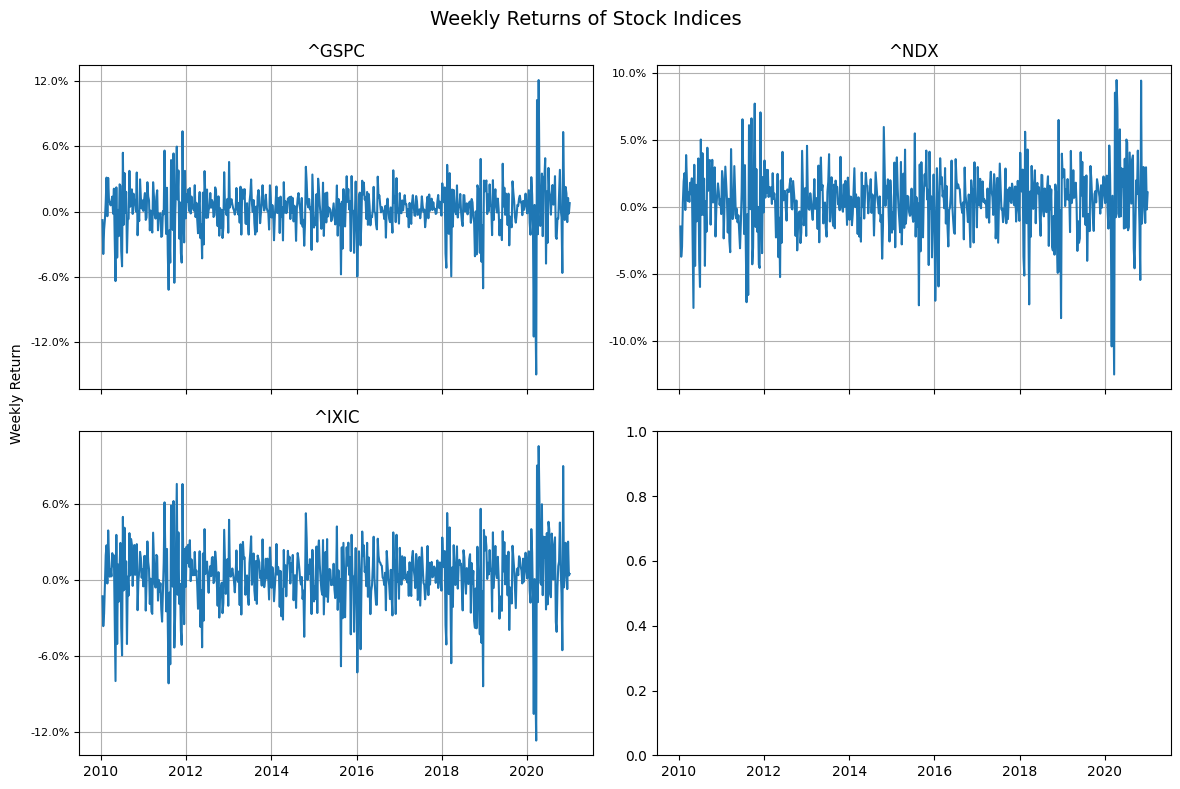

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=False)
axes = axes.flatten()

for i, ticker in enumerate(tickers):
    axes[i].plot(weekly_returns.index, weekly_returns[ticker])
    axes[i].set_title(ticker)
    axes[i].yaxis.set_major_locator(plt.MaxNLocator(5))
    axes[i].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.1%}"))
    axes[i].tick_params(axis='y', labelsize=8)
    axes[i].grid()

fig.suptitle("Weekly Returns of Stock Indices", fontsize=14)
fig.supylabel("Weekly Return", fontsize=10)  # single shared y label
plt.tight_layout()
plt.show()

In [10]:
weekly_returns["^GSPC"].describe(), weekly_returns["^NDX"].describe(), weekly_returns["^IXIC"].describe()

(count    573.000000
 mean       0.002322
 std        0.022618
 min       -0.149796
 25%       -0.007005
 50%        0.003220
 75%        0.014057
 max        0.121017
 Name: ^GSPC, dtype: float64,
 count    573.000000
 mean       0.003666
 std        0.025203
 min       -0.125195
 25%       -0.009332
 50%        0.005146
 75%        0.017795
 max        0.094369
 Name: ^NDX, dtype: float64,
 count    573.000000
 mean       0.003310
 std        0.024948
 min       -0.126397
 25%       -0.008128
 50%        0.004350
 75%        0.017844
 max        0.105858
 Name: ^IXIC, dtype: float64)

In [14]:
R = weekly_returns.to_numpy()
T, n = R.shape
print(f"Shape of R: {R.shape}")
mu_assets = R.mean(axis=0)  
print(f"Mean returns (mu_assets): {mu_assets}")
sigma_assets = R.std(axis=0, ddof=1)
print(f"Standard deviations (sigma_assets): {sigma_assets}")

#p = np.ones(T) / T 



Shape of R: (573, 3)
Mean returns (mu_assets): [0.00232237 0.00330962 0.00366648]
Standard deviations (sigma_assets): [0.02261807 0.02494826 0.02520288]


In [16]:
# save R into CSV file
weekly_returns.to_csv(f"weekly_returns{tickers}.csv", index=True)

print(f"weekly_returns{tickers}.csv")

weekly_returns['^GSPC', '^NDX', '^IXIC'].csv
